<a href="https://colab.research.google.com/github/laysabelici/Unitins-Especializacao-Data-Science/blob/main/AspectosAvancadosPythonP3/atividade02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aspectos Avançados de Python para Ciência de Dados

Notebook para o curso de Pós-Graduação em Ciência de Dados da [Unitins](https://www.unitins.br/posgraduacao/cursos/ciencia-de-dados/).


##Atividade - 01

Você recebeu os arquivos alunos.csv e desempenho.csv de uma universidade. Seu primeiro desafio é explorar e preparar esses arquivos para que possamos iniciar a análise dos dados.


In [14]:
from google.colab import drive
import os
import pandas as pd
import matplotlib.pyplot as plt

#Montar o Drive
drive.mount('/content/drive')

#Caminho da pasta onde estão os arquivos
pasta = '/home/dataset'

#Arquivos locais (sem download)
arquivos = [
    (f'{pasta}/atividade_alunos.csv'),
    (f'{pasta}/atividade_desempenho.csv')
]

#Garantir que a pasta existe
os.makedirs(pasta, exist_ok=True)

#Carregar os arquivos
df_alunos = pd.read_csv(arquivos[0], encoding='utf-8')
df_desempenho = pd.read_csv(arquivos[1], encoding='utf-8')

#Fazer o merge
df = pd.merge(df_alunos, df_desempenho, on='id_aluno', how='inner')
df['id_aluno'] = df['id_aluno'].astype(str)

#Exibir resultados
print('\nDataFrame final:')
display(df.head(5))

print('\nAlunos:')
display(df_alunos.head(5))

print('\nDesempenho:')
display(df_desempenho.head(5))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

DataFrame final:


,curso,nome,sexo,id_aluno,idade_ingresso,cidade_polo,semestre_ingresso,status,semestre,disciplina,media,falta,ch
0,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20231,CADEIAS PRODUTIVAS DA HORTIFRUTICULTURA,9.30,8.0,60.0
1,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20231,CONTABILIDADE RURAL,7.95,0.0,60.0
2,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20231,DESENVOLVIMENTO REGIONAL DO CERRADO E AGRONEGÓCIO,9.10,4.0,60.0
3,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20231,FUNDAMENTOS DE PRODUÇÃO VEGETAL,8.60,15.0,60.0
4,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20231,INTRODUÇÃO À GESTÃO DO AGRONEGÓCIO,9.60,4.0,60.0



Alunos:


,curso,nome,sexo,id_aluno,idade_ingresso,cidade_polo,semestre_ingresso,status
0,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado
1,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 2,F,4863064144,29,PALMAS-TOCANTINS,20231,Graduado
2,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 3,Feminino,3864952505,23,MIRANORTE-TO,20231,Graduado
3,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 4,Masculino,5107643318,18,COLMÉIA,20231,Graduado
4,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 5,M,4893431601,17,PALMAS,20231,Matriculado



Desempenho:


,id_aluno,semestre,disciplina,media,falta,ch
0,1375446035,20231,CADEIAS PRODUTIVAS DA HORTIFRUTICULTURA,7.00,16.0,60.0
1,1375446035,20231,CONTABILIDADE RURAL,7.80,0.0,60.0
2,1375446035,20231,DESENVOLVIMENTO REGIONAL DO CERRADO E AGRONEGÓCIO,7.85,4.0,60.0
3,1375446035,20231,FUNDAMENTOS DE PRODUÇÃO VEGETAL,8.90,3.0,60.0
4,1375446035,20231,INTRODUÇÃO À GESTÃO DO AGRONEGÓCIO,8.35,3.0,60.0


In [15]:
# Inner join: mantém apenas alunos que aparecem nas duas tabelas
df = pd.merge(df_alunos, df_desempenho, on='id_aluno', how='inner')
df['id_aluno'] = df['id_aluno'].astype(str)

#df.head(5)
#df.tail(5)
df.info()
#df.shape
df.columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   curso              295 non-null    object 
 1   nome               295 non-null    object 
 2   sexo               295 non-null    object 
 3   id_aluno           295 non-null    object 
 4   idade_ingresso     295 non-null    int64  
 5   cidade_polo        295 non-null    object 
 6   semestre_ingresso  295 non-null    object 
 7   status             295 non-null    object 
 8   semestre           295 non-null    object 
 9   disciplina         295 non-null    object 
 10  media              257 non-null    float64
 11  falta              295 non-null    float64
 12  ch                 295 non-null    float64
dtypes: float64(3), int64(1), object(9)
memory usage: 30.1+ KB


,idade_ingresso,media,falta,ch
count,295.000000,257.000000,295.000000,295.000000
mean,24.230508,6.192996,18.610169,62.949153
std,6.341293,2.962462,27.715401,8.946979
min,17.000000,0.000000,0.000000,60.000000
25%,19.000000,6.000000,0.000000,60.000000
50%,23.000000,7.000000,4.000000,60.000000
75%,29.000000,8.250000,18.000000,60.000000
max,37.000000,10.000000,115.000000,90.000000


## Atividade - 02

Agora, o reitor da universidade deseja compreender melhor a situação dos alunos. Para isso, decidimos utilizar um gráfico de barras mostrando a quantidade de alunos em cada status e um gráfico de pizza apresentando o percentual em cada status.

Quantidade de alunos no df:  10
Quantidade de status no df:  4
Status que temos no df:  ['Graduado' 'Matriculado' 'Desvinculado' 'Desistente']


/tmp/ipykernel_3115/4208263940.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


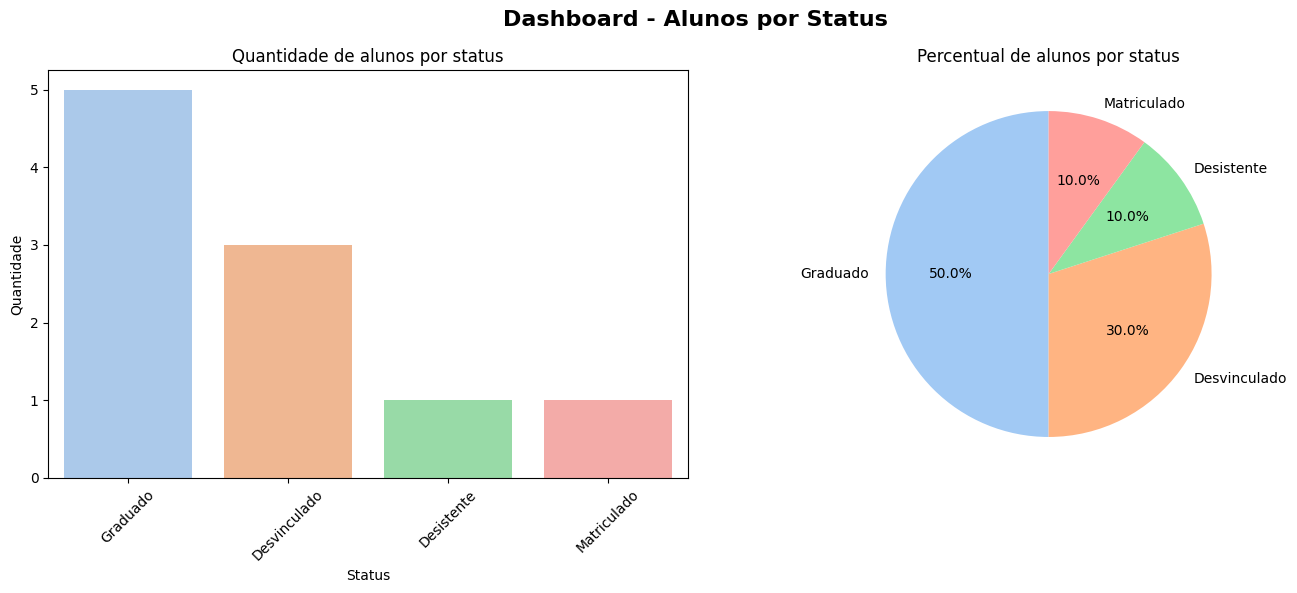

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Analise os dados que serão usados nos gráficos
print('Quantidade de alunos no df: ', df['id_aluno'].nunique())
print('Quantidade de status no df: ', df['status'].nunique())
print('Status que temos no df: ', df['status'].unique())

#Preparação de dados com groupby
contagem_status = df.groupby('status')['id_aluno'].nunique().reset_index()
contagem_status.columns = ['status', 'quantidade']
contagem_status = contagem_status.sort_values('quantidade', ascending=False)

cores = sns.color_palette('pastel', n_colors=len(contagem_status))

#Montagem do dashboard (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#---- Gráfico 1: Barras ----
sns.barplot(
    data=contagem_status,
    x='status',
    y='quantidade',
    palette=cores,
    ax=axes[0]
)
axes[0].set_title('Quantidade de alunos por status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)

#---- Gráfico 2: Pizza ----
axes[1].pie(
    contagem_status['quantidade'],
    labels=contagem_status['status'],
    autopct='%1.1f%%',
    colors=cores,
    startangle=90
)
axes[1].set_title('Percentual de alunos por status')

#---- Dashboard Geral ----
fig.suptitle('Dashboard - Alunos por Status', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


## EXTRA

Professor, adicionei um quadro simples de correlação entre as informações que temos dos alunos e desistencia para chegar a uma analise mais detalhada de caracteristicas sobre essa ação.

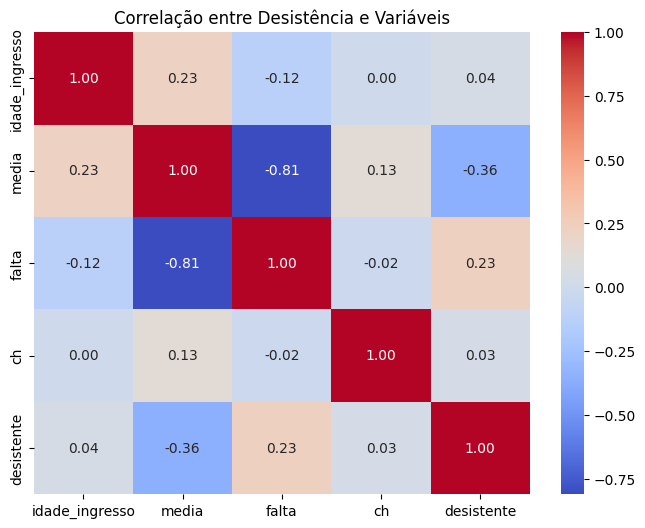

In [17]:
#Criar variável binária para desistência
df['desistente'] = df['status'].apply(lambda x: 1 if x.lower() == 'desistente' else 0)

#Selecionar apenas colunas numéricas relevantes
colunas_numericas = ['idade_ingresso', 'media', 'falta', 'ch', 'desistente']

#Converter idade_ingresso para numérico (caso esteja como string)
df['idade_ingresso'] = pd.to_numeric(df['idade_ingresso'], errors='coerce')

#Calculo de correlação
corr = df[colunas_numericas].corr()

#Plotar heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre Desistência e Variáveis')
plt.show()


## Etapa 3 — Integração e análise

Realize o merge entre as duas tabelas utilizando inner join pelo campo id_aluno.

In [18]:
#Merge entre alunos e desempenho
df = pd.merge(
    df_alunos,
    df_desempenho,
    on='id_aluno',
    how='inner'
)

#Ajuste de tipo para id_aluno (opcional, mas útil para consistência)
df['id_aluno'] = df['id_aluno'].astype(str)

#Visualização inicial
print("DataFrame integrado:")
display(df.head(10))

#Informações gerais
print("\nInformações do DataFrame:")
df.info()

print("\nColunas disponíveis:")
print(df.columns.tolist())

print("\nResumo estatístico:")
display(df.describe(include='all'))


DataFrame integrado:


,curso,nome,sexo,id_aluno,idade_ingresso,cidade_polo,semestre_ingresso,status,semestre,disciplina,media,falta,ch
0,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20231,CADEIAS PRODUTIVAS DA HORTIFRUTICULTURA,9.30,8.0,60.0
1,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20231,CONTABILIDADE RURAL,7.95,0.0,60.0
2,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20231,DESENVOLVIMENTO REGIONAL DO CERRADO E AGRONEGÓCIO,9.10,4.0,60.0
3,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20231,FUNDAMENTOS DE PRODUÇÃO VEGETAL,8.60,15.0,60.0
4,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20231,INTRODUÇÃO À GESTÃO DO AGRONEGÓCIO,9.60,4.0,60.0
5,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20231,METODOLOGIA CIENTÍFICA,9.25,0.0,60.0
6,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20232,ADMINISTRAÇÃO DE SUPRIMENTOS E LOGÍSTICA,8.40,0.0,60.0
7,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20232,ADMINISTRAÇÃO E PLANEJAMENTO RURAL,10.00,0.0,60.0
8,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20232,AGROECOLOGIA E DESENVOLVIMENTO SUSTENTÁVEL,9.00,0.0,60.0
9,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 1,F,7237485195,37,COLMÉIA,2023/1,Graduado,20232,DIREITO APLICADO AO AGRONEGÓCIO,9.70,0.0,60.0



Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   curso              295 non-null    object 
 1   nome               295 non-null    object 
 2   sexo               295 non-null    object 
 3   id_aluno           295 non-null    object 
 4   idade_ingresso     295 non-null    int64  
 5   cidade_polo        295 non-null    object 
 6   semestre_ingresso  295 non-null    object 
 7   status             295 non-null    object 
 8   semestre           295 non-null    object 
 9   disciplina         295 non-null    object 
 10  media              257 non-null    float64
 11  falta              295 non-null    float64
 12  ch                 295 non-null    float64
dtypes: float64(3), int64(1), object(9)
memory usage: 30.1+ KB

Colunas disponíveis:
['curso', 'nome', 'sexo', 'id_aluno', 'idade_ingresso', 'cidade

,curso,nome,sexo,id_aluno,idade_ingresso,cidade_polo,semestre_ingresso,status,semestre,disciplina,media,falta,ch
count,295,295,295,295,295.000000,295,295,295,295,295,257.000000,295.000000,295.000000
unique,1,10,4,10,NaN,6,2,4,11,36,NaN,NaN,NaN
top,TECNOLOGIA EM GESTÃO DO AGRONEGÓCIO,ALUNO 2,F,4863064144,NaN,COLMÉIA,20231,Graduado,20231,FUNDAMENTOS DE PRODUÇÃO VEGETAL,NaN,NaN,NaN
freq,295,50,127,50,NaN,100,256,200,66,13,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,24.230508,NaN,NaN,NaN,NaN,NaN,6.192996,18.610169,62.949153
std,NaN,NaN,NaN,NaN,6.341293,NaN,NaN,NaN,NaN,NaN,2.962462,27.715401,8.946979
min,NaN,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,60.000000
25%,NaN,NaN,NaN,NaN,19.000000,NaN,NaN,NaN,NaN,NaN,6.000000,0.000000,60.000000
50%,NaN,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,NaN,7.000000,4.000000,60.000000
75%,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,8.250000,18.000000,60.000000


## Atividade 02

Agora, o reitor da universidade deseja entender melhor a situação dos alunos por status. Para isso, decidimos utilizar um gráfico de barras mostrando a quantidade de alunos em cada status e um gráfico de pizza apresentando o percentual em cada status.

Além de criar os gráficos, a ideia é entender na prática o uso do groupby() que utilizaremos na hora de fazer a contagem dos alunos, e o nunique(), tendo em vista que um mesmo aluno pode aparecer em mais de um registro.

In [19]:
#Contagem de alunos únicos por status
status_counts = df.groupby('status')['id_aluno'].nunique()

print(status_counts)


status
Desistente      1
Desvinculado    3
Graduado        5
Matriculado     1
Name: id_aluno, dtype: int64


Quantidade de alunos no df:  10
Quantidade de status no df:  4
Status que temos no df:  ['Graduado' 'Matriculado' 'Desvinculado' 'Desistente']


/tmp/ipykernel_3115/2816264848.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


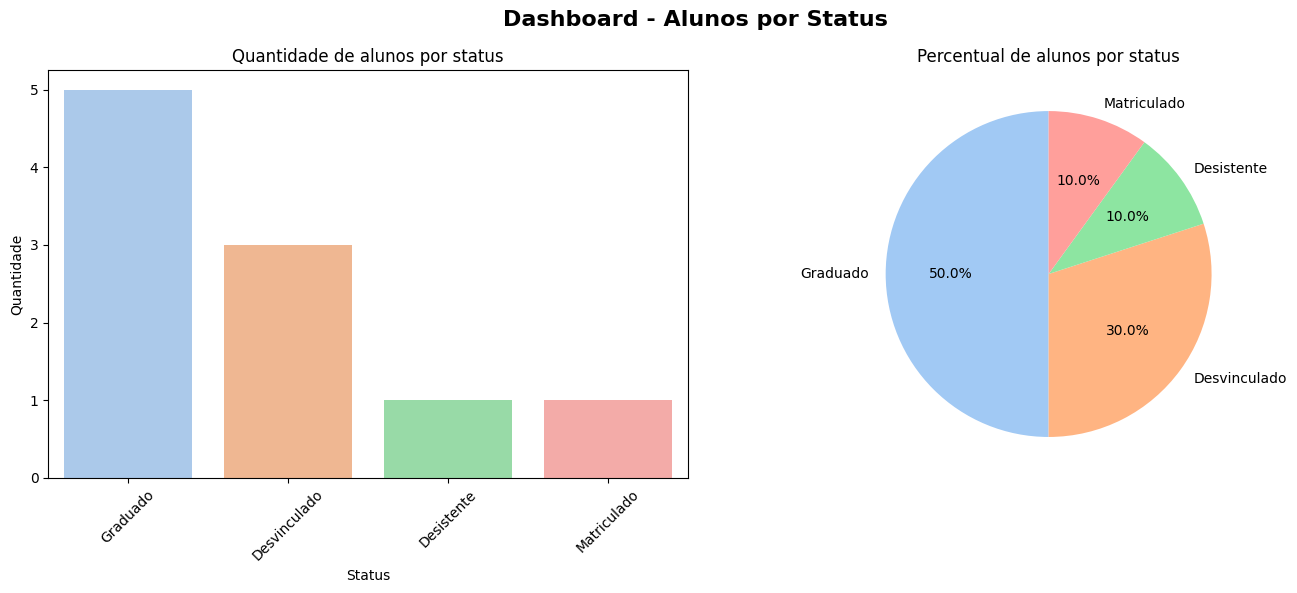

In [25]:
#Análise dos dados que serão usados nos gráficos
print('Quantidade de alunos no df: ', df['id_aluno'].nunique())
print('Quantidade de status no df: ', df['status'].nunique())
print('Status que temos no df: ', df['status'].unique())

#Preparação de dados com groupby
contagem_status = df.groupby('status')['id_aluno'].nunique().reset_index()
contagem_status.columns = ['status', 'quantidade']
contagem_status = contagem_status.sort_values('quantidade', ascending=False)

#Paleta de cores pastel
cores = sns.color_palette('pastel', n_colors=len(contagem_status))

#Montagem do dashboard (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#---- Gráfico 1: Barras ----
sns.barplot(
    data=contagem_status,
    x='status',
    y='quantidade',
    palette=cores,
    ax=axes[0]
)
axes[0].set_title('Quantidade de alunos por status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)

#---- Gráfico 2: Pizza ----
axes[1].pie(
    contagem_status['quantidade'],
    labels=contagem_status['status'],
    autopct='%1.1f%%',
    colors=cores,
    startangle=90
)
axes[1].set_title('Percentual de alunos por status')

#---- Dashboard Geral ----
fig.suptitle('Dashboard - Alunos por Status', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()